# Toy BNN — predictive inspection

Loads `.pt` files from `results/toy_bnns/` and plots the posterior predictive mean ± 2σ against the true function and training points, for each dataset and sampler.

In [1]:
import os
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline

if Path.cwd().name == "notebooks":
    os.chdir("..")

from sazz.scripts.bnns.toy_bnn import build_target, DATASET_CONFIGS, BNNConfig
from sazz.models.neural_networks import FFN
from sazz.utils.bnn_utils import ParamSpec

torch.set_default_dtype(torch.float64)

RESULTS_DIR = Path("results/toy_bnns")
DATA_DIR    = Path("datasets/toy_1d")

SAMPLER_STYLE = {
    #"boomerang":        ("C0", "Boomerang"),
    "sticky_boomerang": ("C1", "Sticky-Boom"),
    "zigzag":           ("C9", "ZigZag"),
    "sticky_zigzag":    ("C3", "Sticky-ZZ"),
    "nuts":             ("C2", "NUTS"),
    #"nuts_horseshoe":          ("C4", "NUTS-HS"),
}

# Discover which (dataset, split) directories have results
available = sorted(
    (p.parent.parent.name, int(p.parent.name.split("_")[1]))
    for p in RESULTS_DIR.glob("*/split_*/boomerang.pt")
)
print("Available (dataset, split):", available)

Available (dataset, split): [('gap', 0), ('hernandez', 0), ('multiscale', 0), ('sharp', 0)]


In [2]:
@torch.no_grad()
def predictive_summary(samples: torch.Tensor, target, x_grid: np.ndarray):
    """Posterior predictive mean and std on a 1-D x grid (original scale).

    Returns mean_orig, total_std_orig — both on the original y scale.
    """
    likelihood = target.meta["model"].likelihood
    noise_std  = likelihood.noise_std

    X_grid = torch.tensor(x_grid[:, None], dtype=torch.float64)
    # Standardise x the same way the dataset was standardised
    X_grid_std = (X_grid - target.meta["x_mean"]) / target.meta["x_std"]

    preds = torch.stack([
        likelihood.predict(beta, X_grid_std).squeeze(-1)
        for beta in samples
    ])  # [S, n_grid], standardised y

    mean_std = preds.mean(0).numpy()
    epi_std  = preds.std(0).numpy()

    y_std  = target.meta["y_std"]
    y_mean = target.meta["y_mean"]
    mean_orig  = mean_std  * y_std + y_mean
    epi_orig   = epi_std   * y_std
    noise_orig = float(noise_std) * y_std
    total_orig = np.sqrt(epi_orig**2 + noise_orig**2)
    return mean_orig, epi_orig, total_orig


def load_split(dataset: str, split_id: int):
    """Load dataset dict and all sampler payloads for one (dataset, split)."""
    data = torch.load(DATA_DIR / f"{dataset}.pt", weights_only=False)
    split_dir = RESULTS_DIR / dataset / f"split_{split_id:02d}"
    runs = {
        p.stem: torch.load(p, weights_only=False)
        for p in sorted(split_dir.glob("*.pt"))
    }
    return data, runs


def make_target_from_payload(payload, data, dataset: str):
    """Reconstruct the BNN target (needed for likelihood.predict)."""
    cfg = BNNConfig(**DATASET_CONFIGS[dataset], noise_std=data["noise_std"])
    target = build_target(data, cfg)
    target.meta["x_mean"] = float(data["x_mean"])
    target.meta["x_std"]  = float(data["x_std"])
    target.meta["y_mean"] = float(data["y_mean"])
    target.meta["y_std"]  = float(data["y_std"])
    return target

## Predictive plots — all available (dataset, split) combinations

Each panel shows:
- **Shaded band**: posterior predictive ±2σ (epistemic + observation noise)
- **Solid line**: posterior predictive mean
- **Black line**: true noiseless function (from `y_test_clean_raw`)
- **Crosses**: training points (original scale)

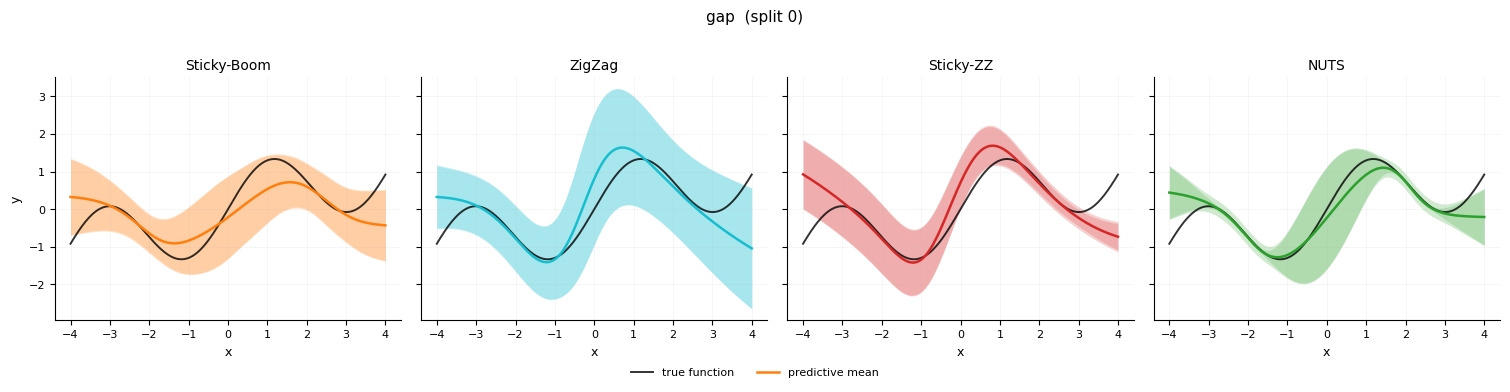

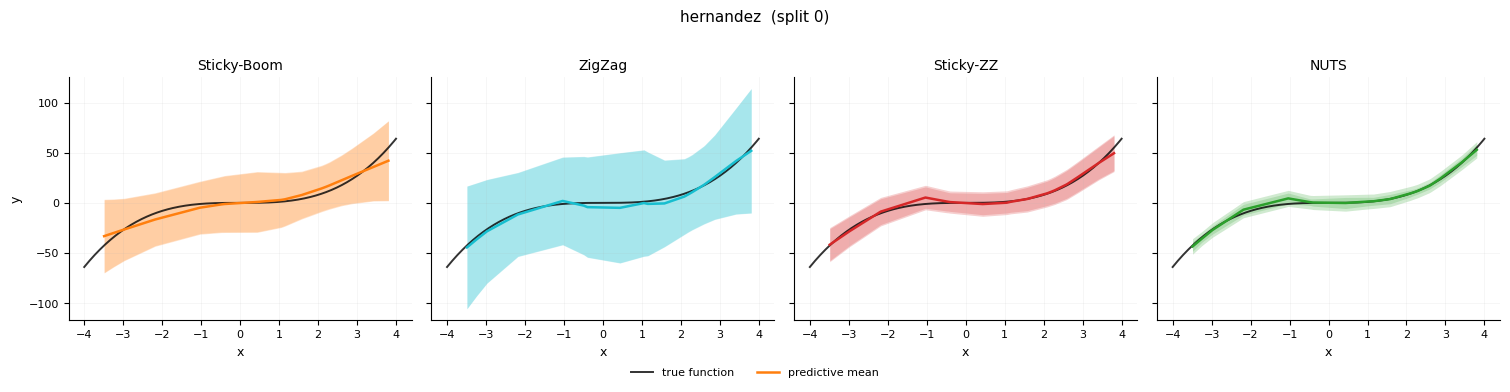

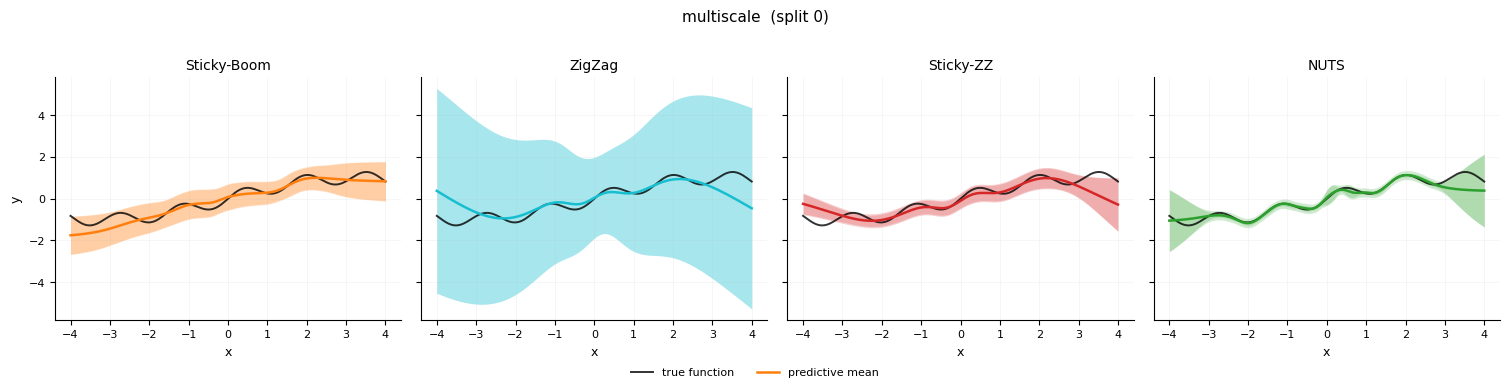

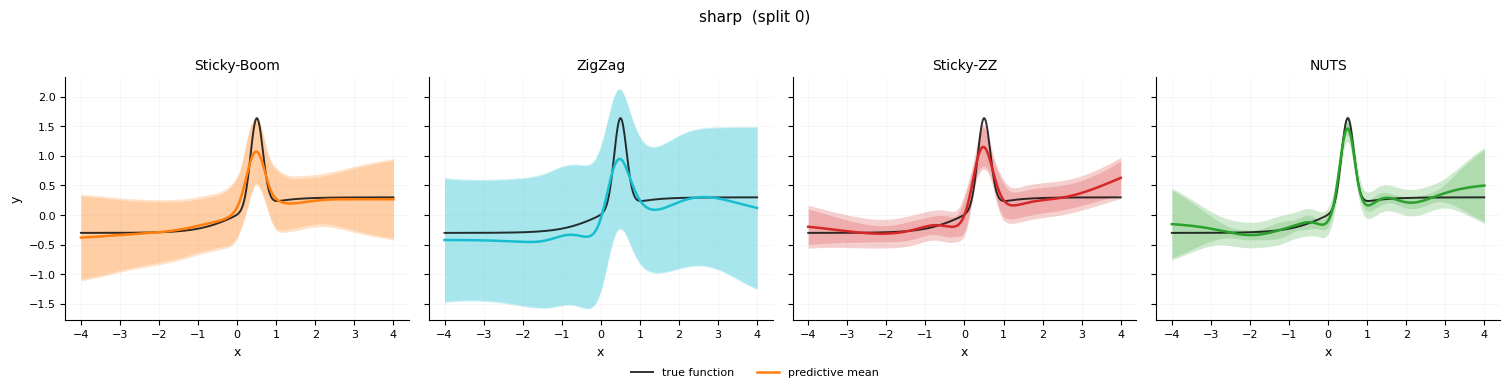

In [3]:
for dataset, split_id in available:
    data, runs = load_split(dataset, split_id)
    target = make_target_from_payload(next(iter(runs.values())), data, dataset)

    x_test   = data["x_test_raw"]          # sorted x for the grid
    y_true   = data["y_test_clean_raw"]     # true noiseless function
    x_train  = data["x_train_raw"]
    y_train  = data["y_train_raw"]

    # Use the test x as the evaluation grid (already dense & sorted)
    if dataset == "hernandez":
        x_grid = np.sort(x_train)
    else:
        x_grid = np.sort(x_test)

    # Sort true function values to match x_grid order
    sort_idx  = np.argsort(x_test)
    x_sorted  = x_test[sort_idx]
    y_sorted  = y_true[sort_idx]

    sampler_keys = [k for k in SAMPLER_STYLE if k in runs]
    n_cols = len(sampler_keys)

    fig, axes = plt.subplots(1, n_cols, figsize=(3.8 * n_cols, 3.6),
                             sharey=True, squeeze=False)

    for col, key in enumerate(sampler_keys):
        ax = axes[0, col]
        color, label = SAMPLER_STYLE[key]

        samples = runs[key]["samples"]  # Tensor [S, D]
        mean, epi, total = predictive_summary(samples, target, x_grid)

        # ±2σ predictive band
        ax.fill_between(x_grid, mean - 2 * total, mean + 2 * total,
                        color=color, alpha=0.22, linewidth=0)
        # Epistemic-only band (inner, slightly more opaque)
        ax.fill_between(x_grid, mean - 2 * epi, mean + 2 * epi,
                        color=color, alpha=0.20, linewidth=0)

        # True function
        ax.plot(x_sorted, y_sorted, color="black", lw=1.4,
                alpha=0.8, zorder=3, label="true function")

        # Posterior predictive mean
        ax.plot(x_grid, mean, color=color, lw=1.8, zorder=4,
                label="predictive mean")

        # Training points
        #ax.scatter(x_train, y_train, marker="x", color="black",
        #           s=40, linewidths=1.2, zorder=5, label="training data")

        ax.set_title(label, fontsize=10)
        ax.set_xlabel("x", fontsize=9)
        if col == 0:
            ax.set_ylabel("y", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.15, linewidth=0.5)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    # Shared legend from first panel
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(handles),
               frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.04))

    fig.suptitle(f"{dataset}  (split {split_id})", fontsize=11, y=1.01)
    fig.tight_layout()
    plt.show()